# Convolution + CNN (MNIST) — optimized notebook

This notebook does two related things:

1. **Hand-made 2D convolution** to build intuition (edge filters like *vertical/horizontal line* and **Sobel**).
2. **A small CNN (Convolutional Neural Network)** trained on **MNIST** digits, plus a more accurate “optimized” variant.

Notes:
- The convolution section uses a **vectorized** implementation (fast) and keeps a **naive loop** version for learning.
- The MNIST loader will try the provided `mnist_train.zip` / `mnist_test.zip` first, and falls back to `keras.datasets.mnist` if those files aren’t present.


In [1]:
import os, random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0


## 1) 2D convolution for edge detection

A 2D convolution slides a small **kernel** (filter) over an image and computes a weighted sum of each local patch.

- If the kernel is designed to respond to **intensity changes**, you get **edges**.
- Different kernels respond to different orientations (vertical edges, horizontal edges, diagonal edges, etc.).


Image shape: (480, 640)


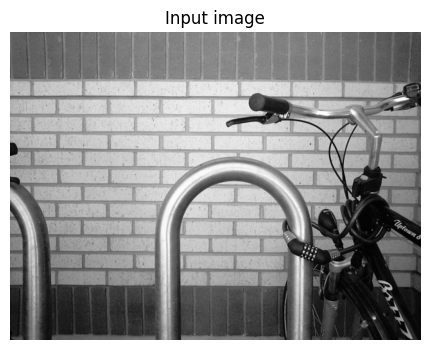

In [2]:
# Load a grayscale image (fallback to a synthetic image if the file isn't present)
img_path = "Bikesgray.png"

if os.path.exists(img_path):
    img = plt.imread(img_path)
else:
    # Fallback synthetic image: a few bright rectangles on dark background
    img = np.zeros((128, 128), dtype=np.float32)
    img[20:45, 15:110] = 0.6
    img[70:110, 30:55] = 1.0
    img[80:100, 75:120] = 0.8

# If image is RGB/RGBA, convert to grayscale
if img.ndim == 3:
    img = img[..., :3]  # drop alpha if present
    img = (0.299*img[...,0] + 0.587*img[...,1] + 0.114*img[...,2])

img = img.astype(np.float32)
print("Image shape:", img.shape)

plt.figure(figsize=(6,4))
plt.imshow(img, cmap="Greys_r")
plt.title("Input image")
plt.axis("off")
plt.show()


### Fast vs. naive convolution

Your original `apply_filter` used nested Python loops. That’s great for understanding, but slow.

Below:
- `apply_filter_naive` = loop version (easy to read)
- `apply_filter` = **vectorized** version using a sliding-window view + `einsum` (much faster, same result).


In [3]:
from numpy.lib.stride_tricks import sliding_window_view

def apply_filter_naive(image: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    """Valid convolution (no padding). Educational loop implementation."""
    image = np.asarray(image, dtype=np.float32)
    kernel = np.asarray(kernel, dtype=np.float32)
    if image.ndim != 2 or kernel.ndim != 2:
        raise ValueError("apply_filter_naive expects 2D image and 2D kernel.")
    h, w = image.shape
    kh, kw = kernel.shape
    out = np.zeros((h - kh + 1, w - kw + 1), dtype=np.float32)
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            out[i, j] = np.sum(image[i:i+kh, j:j+kw] * kernel)
    return out

def apply_filter(image: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    """Valid convolution (no padding). Vectorized & fast."""
    image = np.asarray(image, dtype=np.float32)
    kernel = np.asarray(kernel, dtype=np.float32)
    if image.ndim != 2 or kernel.ndim != 2:
        raise ValueError("apply_filter expects 2D image and 2D kernel.")
    windows = sliding_window_view(image, kernel.shape)  # (H-kh+1, W-kw+1, kh, kw)
    return np.einsum("ijkl,kl->ij", windows, kernel, optimize=True)

# Quick correctness check on a small random example
_test_img = np.random.randn(20, 20).astype(np.float32)
_test_k = np.random.randn(5, 5).astype(np.float32)
max_abs_diff = np.max(np.abs(apply_filter_naive(_test_img, _test_k) - apply_filter(_test_img, _test_k)))
print("Max |naive - fast|:", max_abs_diff)


Max |naive - fast|: 1.9073486e-06


In [4]:
def show_three(original, a, b, title_a="A", title_b="B"):
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1); plt.imshow(original, cmap="Greys_r"); plt.title("Original"); plt.axis("off")
    plt.subplot(1,3,2); plt.imshow(a, cmap="Greys_r"); plt.title(title_a); plt.axis("off")
    plt.subplot(1,3,3); plt.imshow(b, cmap="Greys_r"); plt.title(title_b); plt.axis("off")
    plt.tight_layout()
    plt.show()


### Simple line filters + Sobel filters

- A “line” filter highlights structures aligned with the filter.
- The **Sobel** kernels are classic edge detectors that approximate image gradients.


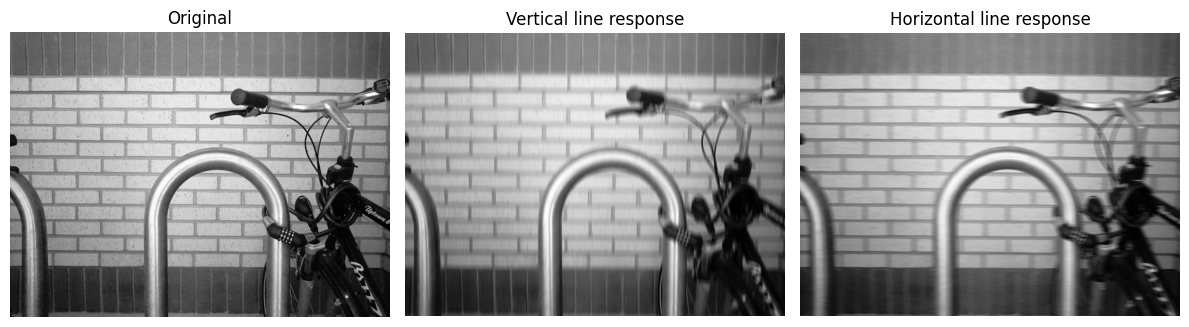

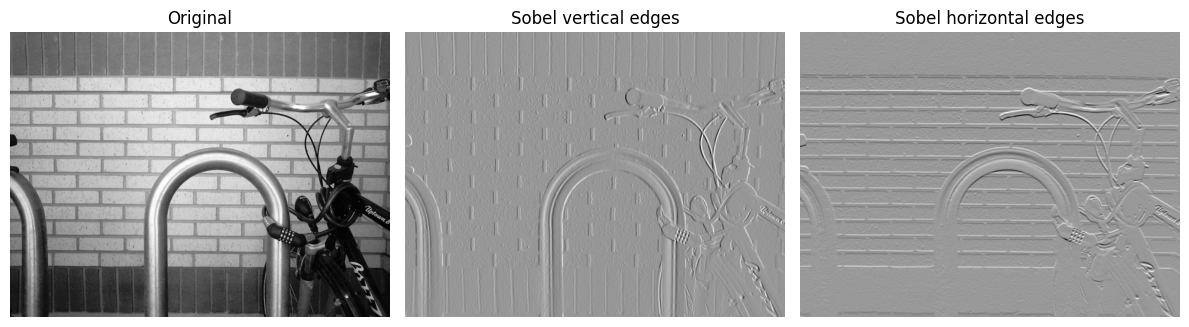

In [5]:
# Simple line filters
filter_size = 11
center = filter_size // 2

filter_v = np.zeros((filter_size, filter_size), dtype=np.float32)
filter_h = np.zeros((filter_size, filter_size), dtype=np.float32)
filter_v[:, center] = 1.0
filter_h[center, :] = 1.0

img_v = apply_filter(img, filter_v)
img_h = apply_filter(img, filter_h)
show_three(img, img_v, img_h, "Vertical line response", "Horizontal line response")

# Sobel filters (vertical & horizontal)
sobel_v = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]], dtype=np.float32)

sobel_h = np.array([[ 1,  2,  1],
                    [ 0,  0,  0],
                    [-1, -2, -1]], dtype=np.float32)

img_sv = apply_filter(img, sobel_v)
img_sh = apply_filter(img, sobel_h)
show_three(img, img_sv, img_sh, "Sobel vertical edges", "Sobel horizontal edges")


## 2) Load + preprocess MNIST

Key preprocessing steps:
- reshape to **(28, 28, 1)** so Conv2D can treat it like an image,
- scale pixels to **[0, 1]** for stable training,
- one-hot encode labels for softmax classification.


In [6]:
def load_mnist():
    """Try CSV zips first, fallback to keras.datasets.mnist."""
    train_zip = "mnist_train.zip"
    test_zip = "mnist_test.zip"
    if os.path.exists(train_zip) and os.path.exists(test_zip):
        train_df = pd.read_csv(train_zip)
        test_df = pd.read_csv(test_zip)
        X_train, y_train = train_df.iloc[:, 1:].to_numpy(), train_df.iloc[:, 0].to_numpy()
        X_test, y_test = test_df.iloc[:, 1:].to_numpy(), test_df.iloc[:, 0].to_numpy()
        X_train = X_train.reshape(-1, 28, 28, 1)
        X_test  = X_test.reshape(-1, 28, 28, 1)
    else:
        (X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
        X_train = X_train[..., None]
        X_test  = X_test[..., None]

    X_train = X_train.astype("float32") / 255.0
    X_test  = X_test.astype("float32") / 255.0

    y_train_oh = keras.utils.to_categorical(y_train, 10)
    y_test_oh  = keras.utils.to_categorical(y_test, 10)

    return (X_train, y_train, y_train_oh), (X_test, y_test, y_test_oh)

(Xtrain, ytrain, Ytrain), (Xtest, ytest, Ytest) = load_mnist()
print("Xtrain:", Xtrain.shape, "Ytrain(one-hot):", Ytrain.shape)


Xtrain: (59999, 28, 28, 1) Ytrain(one-hot): (59999, 10)


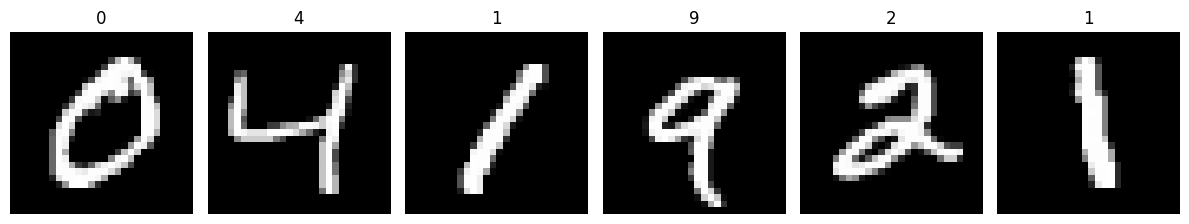

In [7]:
# Quick visualization
plt.figure(figsize=(12,3))
for i in range(6):
    plt.subplot(1,6,i+1)
    plt.imshow(Xtrain[i,...,0], cmap="Greys_r")
    plt.title(str(ytrain[i]))
    plt.axis("off")
plt.tight_layout()
plt.show()


## 3) Training helpers

Using callbacks is a simple “optimization” that improves training hygiene:
- **EarlyStopping**: stop when validation stops improving (prevents overfitting and wasted compute)
- **ReduceLROnPlateau**: lower learning rate automatically when progress stalls


In [8]:
def plot_history(history):
    metrics = history.history
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(metrics.get("loss", []), label="train loss")
    plt.plot(metrics.get("val_loss", []), label="val loss")
    plt.yscale("log")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(metrics.get("accuracy", []), label="train acc")
    plt.plot(metrics.get("val_accuracy", []), label="val acc")
    plt.title("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5),
]


## 4) Baseline CNN (close to your original)

This is intentionally small:
- 1 convolution layer + pooling
- 1 dense softmax layer

It’s good as a baseline, but it usually underfits MNIST a bit.


In [9]:
def build_baseline_cnn():
    return keras.Sequential([
        layers.Input(shape=(28,28,1)),
        layers.Conv2D(8, (3,3), activation="relu"),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(10, activation="softmax"),
    ])

baseline = build_baseline_cnn()
baseline.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[keras.metrics.CategoricalAccuracy(name="accuracy")]
)
baseline.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1352)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        13,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,610 (53.16 KB)

 Trainable params: 13,610 (53.16 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
399/399 - 5s - 12ms/step - accuracy: 0.8597 - loss: 0.5411 - val_accuracy: 0.9373 - val_loss: 0.2272 - learning_rate: 0.0010
Epoch 2/20
399/399 - 3s - 8ms/step - accuracy: 0.9352 - loss: 0.2225 - val_accuracy: 0.9532 - val_loss: 0.1687 - learning_rate: 0.0010
Epoch 3/20
399/399 - 3s - 7ms/step - accuracy: 0.9510 - loss: 0.1715 - val_accuracy: 0.9608 - val_loss: 0.1396 - learning_rate: 0.0010
Epoch 4/20
399/399 - 3s - 7ms/step - accuracy: 0.9588 - loss: 0.1435 - val_accuracy: 0.9640 - val_loss: 0.1231 - learning_rate: 0.0010
Epoch 5/20
399/399 - 3s - 7ms/step - accuracy: 0.9634 - loss: 0.1262 - val_accuracy: 0.9682 - val_loss: 0.1126 - learning_rate: 0.0010
Epoch 6/20
399/399 - 3s - 7ms/step - accuracy: 0.9666 - loss: 0.1143 - val_accuracy: 0.9702 - val_loss: 0.1055 - learning_rate: 0.0010
Epoch 7/20
399/399 - 3s - 7ms/step - accuracy: 0.9692 - loss: 0.1053 - val_accuracy: 0.9718 - val_loss: 0.1001 - learning_rate: 0.0010
Epoch 8/20
399/399 - 3s - 8ms/step - accuracy: 0.9715 

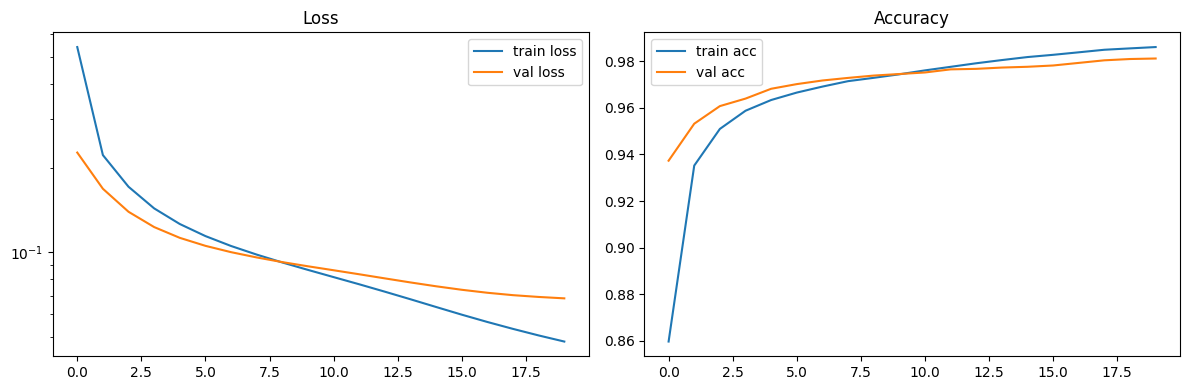

Baseline test accuracy: 0.9792


In [10]:
history_base = baseline.fit(
    Xtrain, Ytrain,
    validation_split=0.15,
    batch_size=128,
    epochs=20,
    shuffle=True,
    callbacks=callbacks,
    verbose=2
)
plot_history(history_base)

test_loss, test_acc = baseline.evaluate(Xtest, Ytest, verbose=0)
print(f"Baseline test accuracy: {test_acc:.4f}")


## 5) Optimized CNN (better accuracy, still simple)

Why this is typically better:
- **More convolutional capacity** (two conv blocks) learns richer features.
- **BatchNorm** stabilizes training (keeps activations well-behaved).
- **Dropout** regularizes (reduces overfitting).
- A small dense layer before softmax gives the model more flexibility.

This is still a “small” CNN—just less sleepy.


In [11]:
def build_optimized_cnn():
    return keras.Sequential([
        layers.Input(shape=(28,28,1)),

        layers.Conv2D(32, (3,3), padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.2),

        layers.Conv2D(64, (3,3), padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(10, activation="softmax"),
    ])

opt_model = build_optimized_cnn()
opt_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[keras.metrics.CategoricalAccuracy(name="accuracy")]
)
opt_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,930 (1.61 MB)

 Trainable params: 421,738 (1.61 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/20
399/399 - 24s - 61ms/step - accuracy: 0.8521 - loss: 0.4706 - val_accuracy: 0.9221 - val_loss: 0.3363 - learning_rate: 0.0010
Epoch 2/20
399/399 - 20s - 51ms/step - accuracy: 0.9479 - loss: 0.1732 - val_accuracy: 0.9857 - val_loss: 0.0536 - learning_rate: 0.0010
Epoch 3/20
399/399 - 21s - 52ms/step - accuracy: 0.9585 - loss: 0.1367 - val_accuracy: 0.9871 - val_loss: 0.0443 - learning_rate: 0.0010
Epoch 4/20
399/399 - 21s - 53ms/step - accuracy: 0.9653 - loss: 0.1127 - val_accuracy: 0.9884 - val_loss: 0.0437 - learning_rate: 0.0010
Epoch 5/20
399/399 - 21s - 53ms/step - accuracy: 0.9700 - loss: 0.1001 - val_accuracy: 0.9881 - val_loss: 0.0401 - learning_rate: 0.0010
Epoch 6/20
399/399 - 22s - 55ms/step - accuracy: 0.9729 - loss: 0.0915 - val_accuracy: 0.9871 - val_loss: 0.0452 - learning_rate: 0.0010
Epoch 7/20
399/399 - 21s - 52ms/step - accuracy: 0.9751 - loss: 0.0839 - val_accuracy: 0.9878 - val_loss: 0.0441 - learning_rate: 0.0010


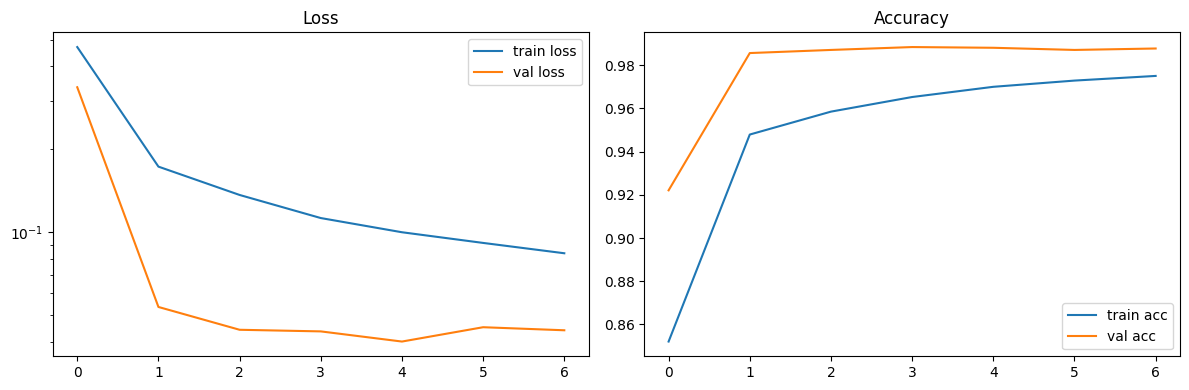

Optimized model test accuracy: 0.9878


In [12]:
history_opt = opt_model.fit(
    Xtrain, Ytrain,
    validation_split=0.15,
    batch_size=128,
    epochs=20,
    shuffle=True,
    callbacks=callbacks,
    verbose=2
)
plot_history(history_opt)

test_loss, test_acc = opt_model.evaluate(Xtest, Ytest, verbose=0)
print(f"Optimized model test accuracy: {test_acc:.4f}")


### Quick evaluation: confusion matrix

A confusion matrix shows *where* the model makes mistakes (e.g., 4 vs 9, 3 vs 5…).


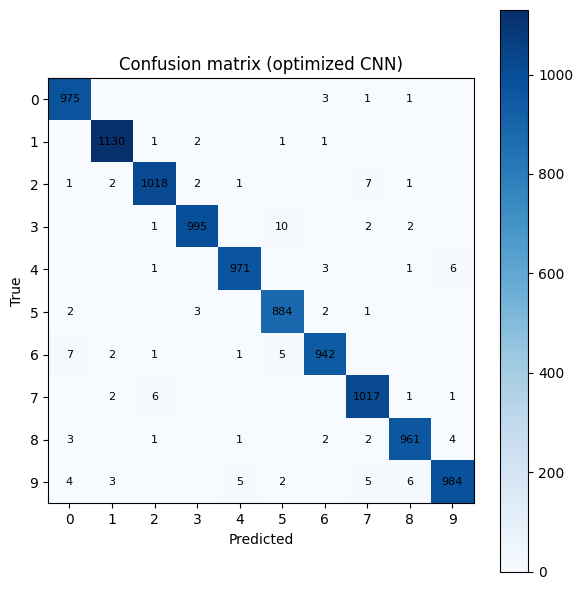

Most common confusions (count, true -> pred):
   10 : 3 -> 5
    7 : 6 -> 0
    7 : 2 -> 7
    6 : 9 -> 8
    6 : 7 -> 2
    6 : 4 -> 9
    5 : 9 -> 7
    5 : 9 -> 4
    5 : 6 -> 5
    4 : 9 -> 0


In [13]:
# Confusion matrix (numpy-only)
y_pred = np.argmax(opt_model.predict(Xtest, verbose=0), axis=1)
cm = np.zeros((10,10), dtype=np.int32)
for t, p in zip(ytest, y_pred):
    cm[t, p] += 1

plt.figure(figsize=(6,6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion matrix (optimized CNN)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.xticks(range(10))
plt.yticks(range(10))
for i in range(10):
    for j in range(10):
        if cm[i,j] > 0:
            plt.text(j, i, str(cm[i,j]), ha="center", va="center", fontsize=8)
plt.tight_layout()
plt.show()

# Show top-10 most common confusions (off-diagonal)
pairs = []
for i in range(10):
    for j in range(10):
        if i != j and cm[i,j] > 0:
            pairs.append((cm[i,j], i, j))
pairs.sort(reverse=True)
print("Most common confusions (count, true -> pred):")
for count, t, p in pairs[:10]:
    print(f"{count:5d} : {t} -> {p}")


## 6) Visualize learned filters (first Conv layer)

This mirrors your original idea: the first conv layer often learns simple edge / stroke detectors.


First conv weights: (3, 3, 1, 32)


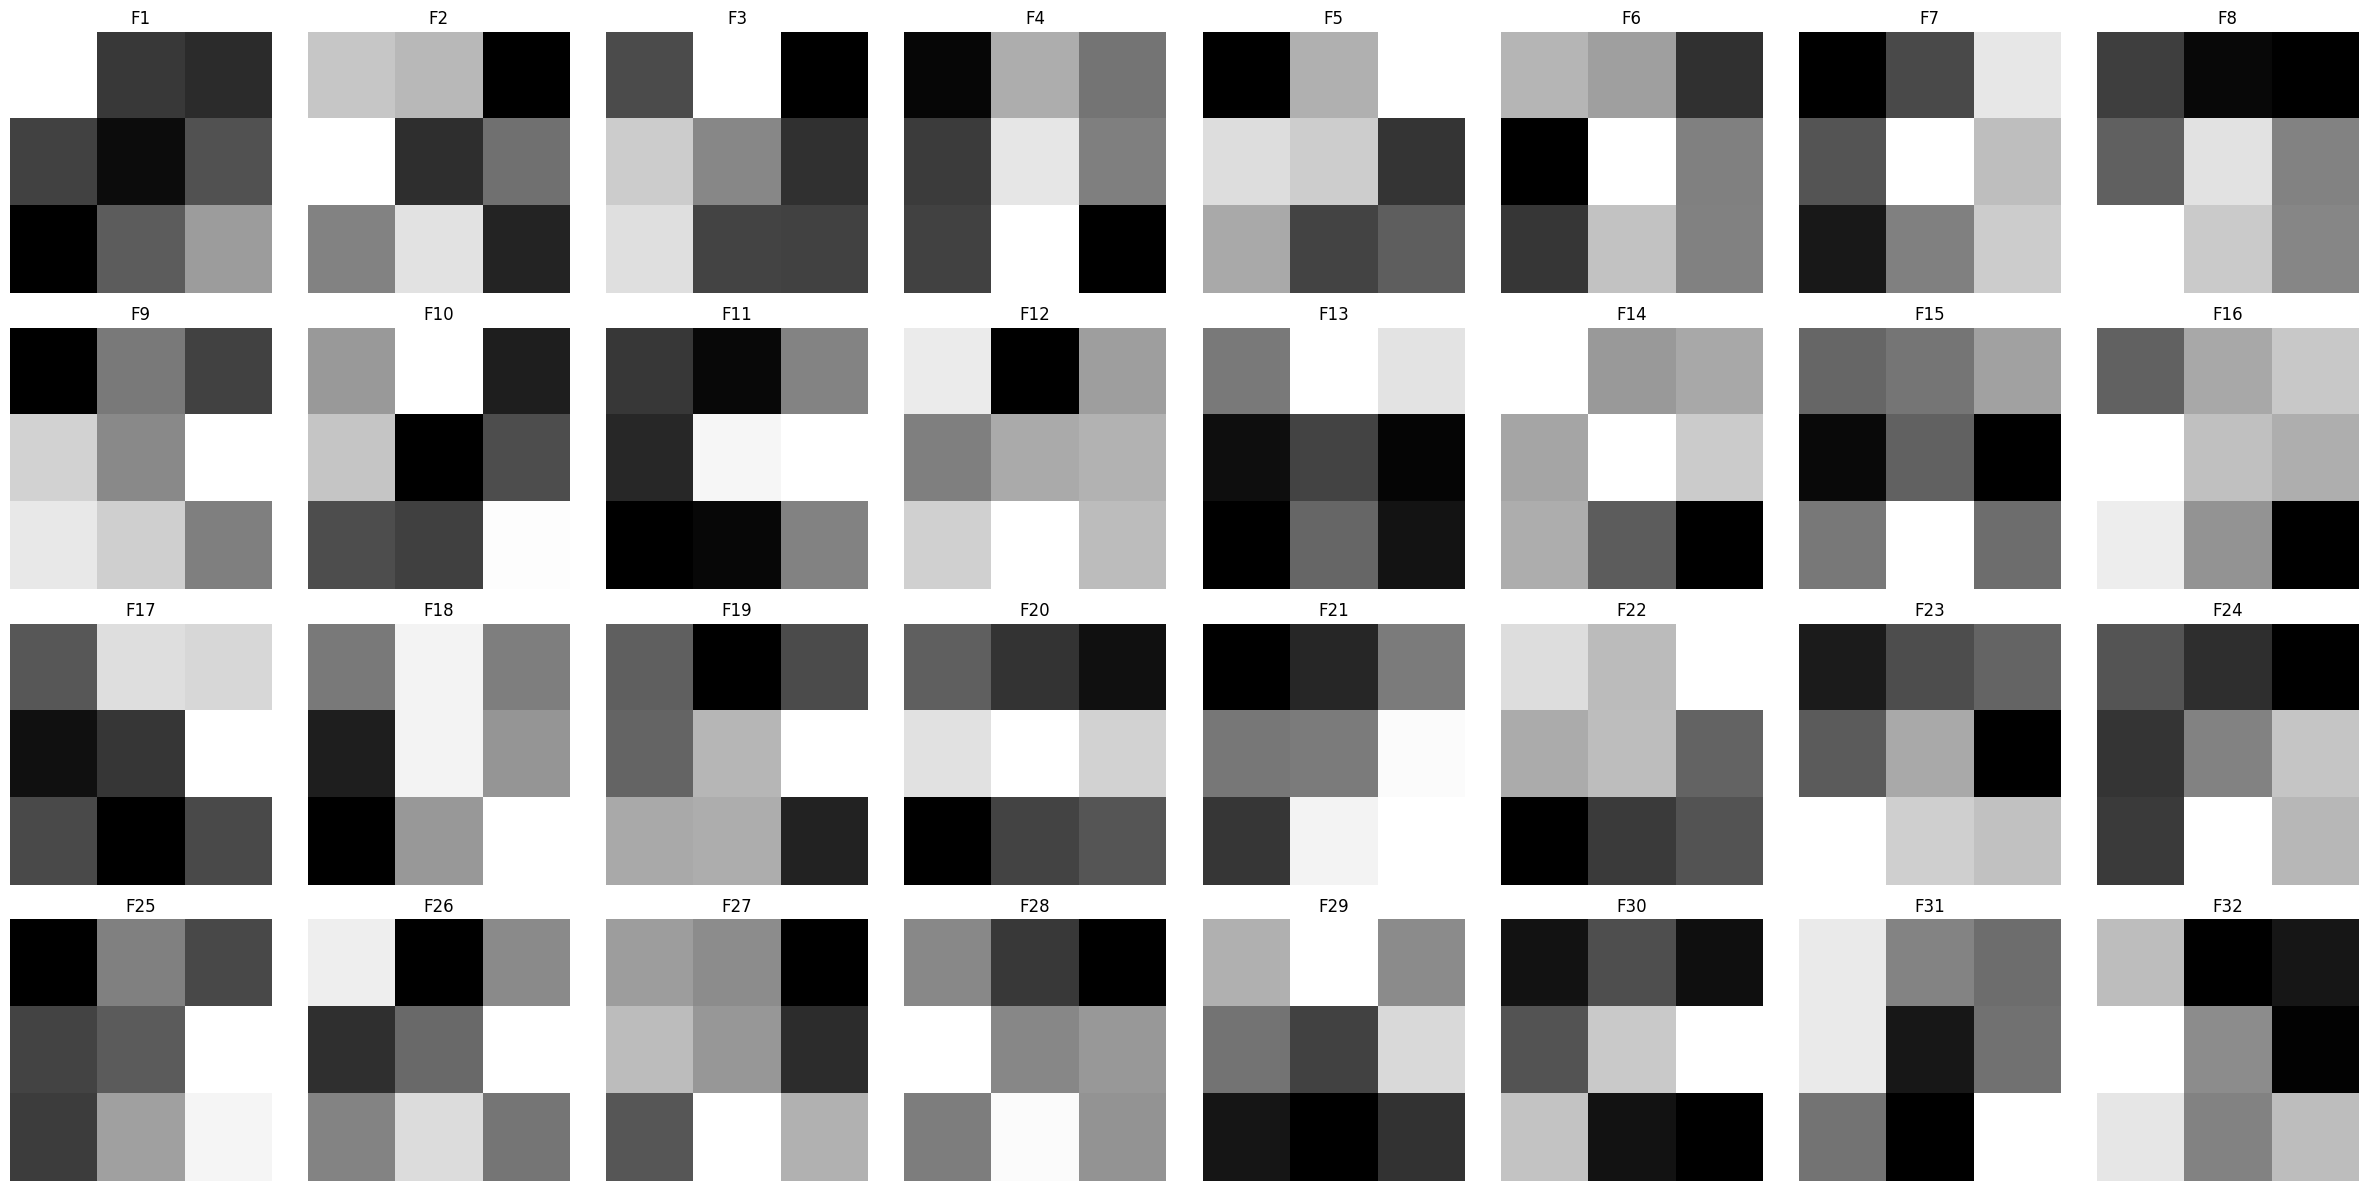

In [14]:
# Get first Conv2D layer weights
first_conv = next(layer for layer in opt_model.layers if isinstance(layer, layers.Conv2D))
w = first_conv.get_weights()[0]  # (kh, kw, in_ch, out_ch)
kh, kw, in_ch, out_ch = w.shape
print("First conv weights:", w.shape)

cols = min(8, out_ch)
rows = (out_ch + cols - 1) // cols
plt.figure(figsize=(3*cols, 3*rows))
for i in range(out_ch):
    plt.subplot(rows, cols, i+1)
    plt.imshow(w[:,:,0,i], cmap="gray")
    plt.title(f"F{i+1}")
    plt.axis("off")
plt.tight_layout()
plt.show()
